In [1]:
import warnings

from pathlib import Path

from datetime import datetime


import numpy as np

import pandas as pd

import pyarrow.parquet as pq

import matplotlib.pyplot as plt


# Modeling and metrics

try:

    from sklearn.compose import ColumnTransformer

    from sklearn.dummy import DummyRegressor

    from sklearn.impute import SimpleImputer

    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    from sklearn.pipeline import Pipeline

    from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer

except ImportError:

    print("Install scikit-learn: pip install scikit-learn")


try:

    from xgboost import XGBRegressor

except ImportError:

    print("Install xgboost: pip install xgboost")


import joblib


warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

plt.style.use('ggplot')

In [2]:
# Configuration
YEAR = 2022
TAXI_TYPE = 'yellow'
PROCESSED_DIR = Path('../processed')
RAW_DIR = Path('../raw')
MODELS_DIR = PROCESSED_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
ZONE_LOOKUP_PATH = RAW_DIR / 'taxi_zone_lookup.csv' if (RAW_DIR / 'taxi_zone_lookup.csv').exists() else Path('../taxi_zone_lookup.csv')

SAMPLE_FRAC = 0.05  # set to 1.0 for full run
MAX_ROWS = None     # optionally cap rows per file post-sample
RANDOM_STATE = 42
TARGET_NAME = 'profit_per_minute'
NUMERIC_CLIP_QUANTILES = (0.005, 0.995)  # winsorize heavy-tailed fields

np.random.seed(RANDOM_STATE)
print(f'Paths set. Will sample {SAMPLE_FRAC*100:.1f}% of each file.' )

Paths set. Will sample 5.0% of each file.


In [3]:
# Load zone lookup to derive lower-cardinality geography features
if ZONE_LOOKUP_PATH.exists():
    zone_lookup = pd.read_csv(ZONE_LOOKUP_PATH)
else:
    print('Zone lookup not found; borough features will be Unknown.')
    zone_lookup = pd.DataFrame(columns=['LocationID', 'Borough', 'Zone', 'service_zone'])

zone_lookup = zone_lookup[['LocationID', 'Borough', 'Zone', 'service_zone']].set_index('LocationID')
zone_lookup.head()

,Borough,Zone,service_zone
LocationID,,,
1,EWR,Newark Airport,EWR
2,Queens,Jamaica Bay,Boro Zone
3,Bronx,Allerton/Pelham Gardens,Boro Zone
4,Manhattan,Alphabet City,Yellow Zone
5,Staten Island,Arden Heights,Boro Zone


In [4]:
# Helper functions
tax_cols = ['congestion_surcharge', 'airport_fee', 'improvement_surcharge', 'mta_tax', 'extra']

def compute_profit_per_minute(df: pd.DataFrame) -> pd.Series:
    for col in ['fare_amount', 'tip_amount', 'tolls_amount'] + tax_cols:
        if col not in df.columns:
            df[col] = 0
    revenue = df['fare_amount'] + df['tip_amount']
    taxes = df[tax_cols].sum(axis=1)
    profit = revenue - df['tolls_amount'] - taxes
    return profit / (df['trip_duration_minutes'] + 2)

def add_time_and_geo_features(df: pd.DataFrame) -> pd.DataFrame:
    df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
    df['hour'] = df['tpep_pickup_datetime'].dt.hour
    df['dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek
    df['month'] = df['tpep_pickup_datetime'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['pickup_borough'] = df['PULocationID'].map(zone_lookup['Borough']).fillna('Unknown')
    df['dropoff_borough'] = df['DOLocationID'].map(zone_lookup['Borough']).fillna('Unknown')
    return df

def clean_rows(df: pd.DataFrame) -> pd.DataFrame:
    df = df[df['qa_flags'] == 0].copy()
    df = df[df['payment_type'] != 0]  # drop corrupt payment cluster
    df = df[(df['trip_distance'] > 0) & (df['trip_duration_minutes'] > 0)]
    return df

def clip_outliers(df: pd.DataFrame, cols, quantiles=(0.01, 0.99)) -> pd.DataFrame:
    lowers = df[cols].quantile(quantiles[0])
    uppers = df[cols].quantile(quantiles[1])
    df[cols] = df[cols].clip(lower=lowers, upper=uppers, axis=1)
    return df

def temporal_split(df: pd.DataFrame, time_col: str, train_q=0.70, val_q=0.85):
    df_sorted = df.sort_values(time_col)
    train_end = df_sorted[time_col].quantile(train_q)
    val_end = df_sorted[time_col].quantile(val_q)
    train = df_sorted[df_sorted[time_col] <= train_end]
    val = df_sorted[(df_sorted[time_col] > train_end) & (df_sorted[time_col] <= val_end)]
    test = df_sorted[df_sorted[time_col] > val_end]
    return train, val, test

In [6]:
# Build modeling dataframe in a memory-aware loop
trip_files = sorted(PROCESSED_DIR.glob(f'{TAXI_TYPE}_tripdata_{YEAR}-*.parquet'))
if not trip_files:
    raise FileNotFoundError('No processed Parquet files found. Run 2_process.ipynb first.')

required_cols = [
    'tpep_pickup_datetime','qa_flags','payment_type','VendorID','RatecodeID','passenger_count',
    'trip_distance','trip_duration_minutes','fare_amount','tip_amount','tolls_amount',
    'improvement_surcharge','congestion_surcharge','airport_fee','mta_tax','extra','total_amount',
    'PULocationID','DOLocationID'
]

schema_cols = set(pq.ParquetFile(trip_files[0]).schema_arrow.names)
available_cols = [c for c in required_cols if c in schema_cols]
missing_cols = sorted(set(required_cols) - schema_cols)
if missing_cols:
    print(f'Missing columns will be filled with zeros: {missing_cols}')

frames = []
for path in trip_files:
    df = pd.read_parquet(path, columns=available_cols)
    if SAMPLE_FRAC and SAMPLE_FRAC < 1.0:
        df = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
    if MAX_ROWS:
        df = df.head(MAX_ROWS)
    for col in missing_cols:
        df[col] = 0
    df = add_time_and_geo_features(df)
    df = clean_rows(df)
    df[TARGET_NAME] = compute_profit_per_minute(df)
    frames.append(df)
    print(f'{path.name}: kept {len(df):,} rows after QA filters')

model_df = pd.concat(frames, ignore_index=True)
clip_cols = ['trip_distance','trip_duration_minutes',TARGET_NAME]
model_df = clip_outliers(model_df, clip_cols, quantiles=NUMERIC_CLIP_QUANTILES)
print(f'Modeling dataframe shape: {model_df.shape}')
model_df.head()

yellow_tripdata_2022-01.parquet: kept 82,811 rows after QA filters
yellow_tripdata_2022-02.parquet: kept 99,929 rows after QA filters
yellow_tripdata_2022-03.parquet: kept 122,755 rows after QA filters
yellow_tripdata_2022-04.parquet: kept 121,467 rows after QA filters
yellow_tripdata_2022-05.parquet: kept 119,282 rows after QA filters
yellow_tripdata_2022-06.parquet: kept 118,232 rows after QA filters
yellow_tripdata_2022-07.parquet: kept 107,491 rows after QA filters
yellow_tripdata_2022-08.parquet: kept 108,263 rows after QA filters
yellow_tripdata_2022-09.parquet: kept 107,314 rows after QA filters
yellow_tripdata_2022-10.parquet: kept 123,467 rows after QA filters
yellow_tripdata_2022-11.parquet: kept 118,391 rows after QA filters
yellow_tripdata_2022-12.parquet: kept 116,438 rows after QA filters
Modeling dataframe shape: (1345840, 30)


,tpep_pickup_datetime,qa_flags,payment_type,VendorID,RatecodeID,passenger_count,trip_distance,trip_duration_minutes,fare_amount,tip_amount,tolls_amount,improvement_surcharge,congestion_surcharge,airport_fee,mta_tax,extra,total_amount,PULocationID,DOLocationID,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,pickup_borough,dropoff_borough,profit_per_minute
0,2022-01-19 18:41:39,0,1,2,1.0,1.0,3.73,14.833333,13.5,3.56,0.0,0.3,2.5,0.0,0.5,1.0,21.36,141,24,18,2,1,0,-1.000000,-1.836970e-16,0.974928,-0.222521,Manhattan,Manhattan,0.758020
1,2022-01-08 10:35:44,0,1,2,1.0,1.0,5.96,10.150000,17.5,4.16,0.0,0.3,2.5,0.0,0.5,0.0,24.96,231,140,10,5,1,1,0.500000,-8.660254e-01,-0.974928,-0.222521,Manhattan,Manhattan,1.511111
2,2022-01-26 20:08:13,0,2,2,1.0,2.0,0.69,4.033333,5.0,0.00,0.0,0.3,2.5,0.0,0.5,0.5,8.80,229,162,20,2,1,0,-0.866025,5.000000e-01,0.974928,-0.222521,Manhattan,Manhattan,0.198895
3,2022-01-15 11:18:32,0,1,2,1.0,1.0,2.73,12.350000,11.5,1.00,0.0,0.3,2.5,0.0,0.5,0.0,15.80,142,263,11,5,1,1,0.258819,-9.659258e-01,-0.974928,-0.222521,Manhattan,Manhattan,0.641115
4,2022-01-04 13:31:02,0,1,2,1.0,1.0,3.26,17.333333,14.0,3.46,0.0,0.3,2.5,0.0,0.5,0.0,20.76,186,140,13,1,1,0,-0.258819,-9.659258e-01,0.781831,0.623490,Manhattan,Manhattan,0.732414


In [7]:
# Persist the prepared modeling set for reproducibility
dataset_path = PROCESSED_DIR / 'profitability_model_dataset.parquet'
model_df.to_parquet(dataset_path, index=False)
print(f'Saved prepared sample to {dataset_path}')

# Quick sanity stats
model_df[[TARGET_NAME,'trip_distance','trip_duration_minutes']].describe(percentiles=[0.5,0.9,0.99]).T

Saved prepared sample to ../processed/profitability_model_dataset.parquet


,count,mean,std,min,50%,90%,99%,max
profit_per_minute,1345840.0,0.662750,0.305651,0.02416,0.61194,0.987342,1.88954,2.453254
trip_distance,1345840.0,3.566755,4.396905,0.17000,1.91000,9.250000,20.37000,21.870000
trip_duration_minutes,1345840.0,15.659642,12.246390,1.25000,12.20000,30.783333,64.40000,73.516667


In [9]:
# Data quality snapshot and skew check
quality_cols = [
    TARGET_NAME,
    'trip_distance','trip_duration_minutes','passenger_count',
    'hour','dayofweek','month','is_weekend','VendorID','RatecodeID',
    'PULocationID','DOLocationID','pickup_borough','dropoff_borough'
]

missing = model_df[quality_cols].isna().sum().sort_values(ascending=False)
missing_nonzero = missing[missing > 0]
print('Missing values (non-zero only):')
print(missing_nonzero if not missing_nonzero.empty else 'None detected')

numeric_overview_cols = [TARGET_NAME,'trip_distance','trip_duration_minutes']
dist_summary = model_df[numeric_overview_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T
skew = model_df[numeric_overview_cols].skew().to_frame(name='skew')

print('\nDistribution summary:')
dist_summary_with_skew = dist_summary.join(skew)
dist_summary_with_skew

Missing values (non-zero only):
None detected

Distribution summary:


,count,mean,std,min,50%,90%,95%,99%,max,skew
profit_per_minute,1345840.0,0.662750,0.305651,0.02416,0.61194,0.987342,1.215052,1.88954,2.453254,2.166790
trip_distance,1345840.0,3.566755,4.396905,0.17000,1.91000,9.250000,15.960000,20.37000,21.870000,2.434867
trip_duration_minutes,1345840.0,15.659642,12.246390,1.25000,12.20000,30.783333,40.766667,64.40000,73.516667,1.969825


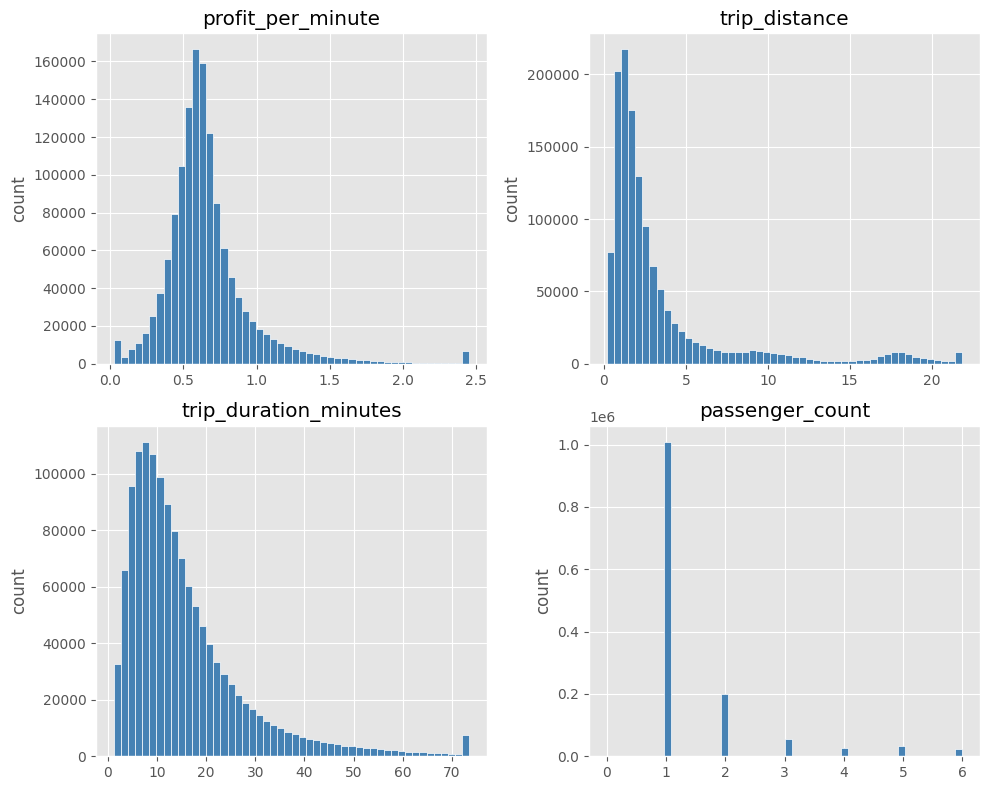

In [10]:
# Visual inspection of key distributions
plot_cols = [TARGET_NAME, 'trip_distance', 'trip_duration_minutes', 'passenger_count']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for col, ax in zip(plot_cols, axes.ravel()):
    ax.hist(model_df[col], bins=50, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

In [12]:
# Train/val/test split by time and build pre-dispatch features
train_df, val_df, test_df = temporal_split(model_df, 'tpep_pickup_datetime', train_q=0.70, val_q=0.85)
print(f'Train: {len(train_df):,}, Val: {len(val_df):,}, Test: {len(test_df):,}')

# Expected distance lookup from training data only
distance_lookup = train_df.groupby(['PULocationID', 'DOLocationID'])['trip_distance'].mean()
global_mean_distance = distance_lookup.mean()

def map_expected_distance(df: pd.DataFrame) -> pd.Series:
    pairs = pd.MultiIndex.from_arrays([df['PULocationID'].values, df['DOLocationID'].values])
    expected = distance_lookup.reindex(pairs)
    expected_filled = expected.fillna(global_mean_distance)
    expected_filled.index = df.index  # align back to dataframe index
    return expected_filled

train_df['expected_distance'] = map_expected_distance(train_df)
val_df['expected_distance'] = map_expected_distance(val_df)
test_df['expected_distance'] = map_expected_distance(test_df)

# Target encoding for pickup location (train-only statistics)
pu_target_mean = train_df.groupby('PULocationID')[TARGET_NAME].mean()
global_target_mean = train_df[TARGET_NAME].mean()
train_df['pu_target_enc'] = train_df['PULocationID'].map(pu_target_mean).fillna(global_target_mean)
val_df['pu_target_enc'] = val_df['PULocationID'].map(pu_target_mean).fillna(global_target_mean)
test_df['pu_target_enc'] = test_df['PULocationID'].map(pu_target_mean).fillna(global_target_mean)

feature_cols = [
    'expected_distance','passenger_count','month','is_weekend',
    'hour_sin','hour_cos','dow_sin','dow_cos','pu_target_enc',
    'VendorID','RatecodeID','DOLocationID','pickup_borough','dropoff_borough'
]

X_train, y_train = train_df[feature_cols], train_df[TARGET_NAME]
X_val, y_val = val_df[feature_cols], val_df[TARGET_NAME]
X_test, y_test = test_df[feature_cols], test_df[TARGET_NAME]

Train: 942,088, Val: 201,876, Test: 201,876


In [13]:
# Preprocessing pipeline for pre-dispatch features
numeric_features = [
    'expected_distance','passenger_count','month','is_weekend',
    'hour_sin','hour_cos','dow_sin','dow_cos','pu_target_enc'
]
categorical_features = ['VendorID','RatecodeID','DOLocationID','pickup_borough','dropoff_borough']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)
preprocess

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [14]:
# Baseline model for reference
baseline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', DummyRegressor(strategy='median'))
])
baseline.fit(X_train, y_train)


def evaluate(model, X, y):
    preds = model.predict(X)
    mae = mean_absolute_error(y, preds)
    rmse = mean_squared_error(y, preds) ** 0.5
    r2 = r2_score(y, preds)
    return {'mae': mae, 'rmse': rmse, 'r2': r2}


baseline_scores = {
    'val': evaluate(baseline, X_val, y_val),
    'test': evaluate(baseline, X_test, y_test)
}
baseline_scores

{'val': {'mae': 0.1862676162588258,
  'rmse': 0.30351076402072813,
  'r2': -0.02343656587068832},
 'test': {'mae': 0.2199594808463277,
  'rmse': 0.3533303122467232,
  'r2': -0.07187918423288342}}

In [15]:
# XGBoost regressor
xgb_reg = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    eval_metric='rmse',
    n_jobs=4,
    random_state=RANDOM_STATE
)

xgb_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', xgb_reg)
])

xgb_pipeline.fit(X_train, y_train)

val_scores = evaluate(xgb_pipeline, X_val, y_val)
test_scores = evaluate(xgb_pipeline, X_test, y_test)
{'val': val_scores, 'test': test_scores}

{'val': {'mae': 0.11153294754295791,
  'rmse': 0.1605185915486123,
  'r2': 0.7137381889564525},
 'test': {'mae': 0.14329419539472815,
  'rmse': 0.2092406326750612,
  'r2': 0.6240967403767061}}

In [16]:
# Feature importance snapshot
num_names = numeric_features
cat_encoder = xgb_pipeline.named_steps['preprocess'].named_transformers_['cat'].named_steps['encoder']
cat_names = cat_encoder.get_feature_names_out(categorical_features)
feature_names = np.concatenate([num_names, cat_names])
importances = pd.Series(xgb_pipeline.named_steps['model'].feature_importances_, index=feature_names)
top_importances = importances.sort_values(ascending=False).head(20)
top_importances

RatecodeID_1.0               0.136089
expected_distance            0.057937
dropoff_borough_Manhattan    0.046031
RatecodeID_5.0               0.033639
RatecodeID_2.0               0.029195
DOLocationID_1               0.026184
DOLocationID_265             0.024277
DOLocationID_243             0.020098
RatecodeID_4.0               0.018577
DOLocationID_244             0.017438
DOLocationID_132             0.014227
RatecodeID_3.0               0.013979
DOLocationID_138             0.013383
pickup_borough_Queens        0.012118
dropoff_borough_Queens       0.011014
DOLocationID_88              0.009358
pickup_borough_Manhattan     0.009258
dropoff_borough_Unknown      0.009153
DOLocationID_166             0.008735
DOLocationID_127             0.008689
dtype: float32

In [17]:
# Persist artifacts
model_path = MODELS_DIR / 'xgb_profitability_pre_dispatch.pkl'
joblib.dump(xgb_pipeline, model_path)
print(f'Saved model to {model_path}')

metrics_path = MODELS_DIR / 'xgb_profitability_pre_dispatch_metrics.json'
pd.Series({
    'baseline_val_mae': baseline_scores['val']['mae'],
    'baseline_val_rmse': baseline_scores['val']['rmse'],
    'baseline_val_r2': baseline_scores['val']['r2'],
    'baseline_test_mae': baseline_scores['test']['mae'],
    'baseline_test_rmse': baseline_scores['test']['rmse'],
    'baseline_test_r2': baseline_scores['test']['r2'],
    'xgb_val_mae': val_scores['mae'],
    'xgb_val_rmse': val_scores['rmse'],
    'xgb_val_r2': val_scores['r2'],
    'xgb_test_mae': test_scores['mae'],
    'xgb_test_rmse': test_scores['rmse'],
    'xgb_test_r2': test_scores['r2'],
}).to_json(metrics_path)
print(f'Saved metrics to {metrics_path}')

Saved model to ../processed/models/xgb_profitability_pre_dispatch.pkl
Saved metrics to ../processed/models/xgb_profitability_pre_dispatch_metrics.json
